# 6.1 Data prepair

In [3]:
data = 'https://raw.githubusercontent.com/gastonstat/CreditScoring/master/CreditScoring.csv'

In [4]:
!wget $data

--2026-01-06 04:25:36--  https://raw.githubusercontent.com/gastonstat/CreditScoring/master/CreditScoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182489 (178K) [text/plain]
Saving to: ‘CreditScoring.csv’

CreditScoring.csv   100%[===================>] 178.21K  --.-KB/s    in 0.1s    

2026-01-06 04:25:37 (1.40 MB/s) - ‘CreditScoring.csv’ saved [182489/182489]



In [6]:
!head CreditScoring.csv

"Status","Seniority","Home","Time","Age","Marital","Records","Job","Expenses","Income","Assets","Debt","Amount","Price"
1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
1,0,1,36,26,1,1,1,46,107,0,0,310,910
1,1,2,60,36,2,1,1,75,214,3500,0,650,1645
1,29,2,60,44,2,1,1,75,125,10000,0,1600,1800
1,9,5,12,27,1,1,1,35,80,0,0,200,1093
1,0,2,60,32,2,1,3,90,107,15000,0,1200,1957


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
df = pd.read_csv("CreditScoring.csv")

In [3]:
df.columns = df.columns.str.lower().str.replace(" ","_")

In [4]:
status_values = {
    1: 'ok',
    2: 'defualt',
    3: 'unk'
}
df.status = df.status.map(status_values)

In [5]:
home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}

df.home = df.home.map(home_values)

marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}

df.marital = df.marital.map(marital_values)

records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}

df.records = df.records.map(records_values)

job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}

df.job = df.job.map(job_values)

In [6]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,defualt,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910


In [7]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [8]:
for c in ['income','assets','debt']:
    df[c] = df[c].replace(to_replace=99999999, value=np.nan)

In [9]:
df = df[df.status != 'unk'].reset_index(drop='True')

In [10]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=11)
df_train, df_val = train_test_split(df_full_train, test_size=0.2, random_state=11)

In [11]:
df_train = df_train.reset_index(drop='True')
df_val = df_val.reset_index(drop='True')
df_test = df_test.reset_index(drop='True')

In [12]:
y_train = (df_train.status == 'defualt').astype('int').values
y_val = (df_val.status == 'defualt').astype('int').values
y_test = (df_test.status == 'defualt').astype('int').values

In [13]:
del df_train['status']
del df_val['status']
del df_test['status']

# 6.2 Decision Trees

In [14]:
def asses_risk(client):
    if client['records'] == 'yes':
        if client['job'] == 'parttime':
            return 'default'
        else:
            return 'ok'
    else:
        if client['assets'] > 6000:
            return 'ok'
        else:
            return 'default'

In [15]:
xi = df_train.iloc[0].to_dict()

In [16]:
asses_risk(xi)

'ok'

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score

In [18]:
train_dicts = df_train.fillna(0).to_dict(orient='records')

In [19]:
dv = DictVectorizer(sparse = False)
X_train = dv.fit_transform(train_dicts)

In [20]:
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [21]:
val_dicts = df_val.fillna(0).to_dict(orient='records')
X_val = dv.fit_transform(val_dicts)

In [22]:
y_pred = dt.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_val,y_pred)
y_pred1 = dt.predict_proba(X_train)[:,1]
auc1 = roc_auc_score(y_train,y_pred1)
print("auc_score(train_data):",auc1)
print("auc_score(val_data):",auc)

auc_score(train_data): 0.7659232334296519
auc_score(val_data): 0.7589331877980122


In [23]:
from sklearn.tree import export_text

In [24]:
print(export_text(dt, feature_names = dv.get_feature_names_out()))

|--- records=yes <= 0.50
|   |--- job=partime <= 0.50
|   |   |--- income <= 73.50
|   |   |   |--- class: 0
|   |   |--- income >  73.50
|   |   |   |--- class: 0
|   |--- job=partime >  0.50
|   |   |--- time <= 27.00
|   |   |   |--- class: 0
|   |   |--- time >  27.00
|   |   |   |--- class: 1
|--- records=yes >  0.50
|   |--- seniority <= 2.50
|   |   |--- assets <= 13500.00
|   |   |   |--- class: 1
|   |   |--- assets >  13500.00
|   |   |   |--- class: 0
|   |--- seniority >  2.50
|   |   |--- income <= 106.50
|   |   |   |--- class: 1
|   |   |--- income >  106.50
|   |   |   |--- class: 0



# 6.5 - Decision Trees Parameter Tuning

In [25]:
for d in [1,2,3,4,5,6,10,15,20,None]:
    dt = DecisionTreeClassifier(max_depth=d)
    dt.fit(X_train,y_train)

    y_pred = dt.predict_proba(X_val)[:,1]
    auc_score = roc_auc_score(y_val,y_pred)

    print("%4s -> %.3f"%(d,auc_score))
    

   1 -> 0.610
   2 -> 0.680
   3 -> 0.759
   4 -> 0.788
   5 -> 0.771
   6 -> 0.762
  10 -> 0.677
  15 -> 0.644
  20 -> 0.661
None -> 0.654


In [29]:
score = []
for d in [4,5,6]:
    for s in [1,2,5,10,15,20,100,200,500]:
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)
        dt.fit(X_train,y_train)
    
        y_pred = dt.predict_proba(X_val)[:,1]
        auc_score = roc_auc_score(y_val,y_pred)
    
        score.append((d,s,auc_score))

In [34]:
columns = ['max_depth','min_leaf','auc_score']
df_score = pd.DataFrame(score, columns=columns)
df_pivot = df_score.pivot(index='min_leaf', columns=['max_depth'],values=['auc_score'])
df_pivot

auc_score                    
max_depth         4         5         6
min_leaf                               
1          0.783315  0.776795  0.771993
2          0.783315  0.773396  0.766445
5          0.788079  0.779500  0.769743
10         0.784397  0.784866  0.780261
15         0.780491  0.779854  0.782846
20         0.788667  0.783382  0.798314
100        0.775584  0.782587  0.797055
200        0.780481  0.780941  0.796672
500        0.679348  0.679348  0.679348

<Axes: xlabel='None-max_depth', ylabel='min_leaf'>

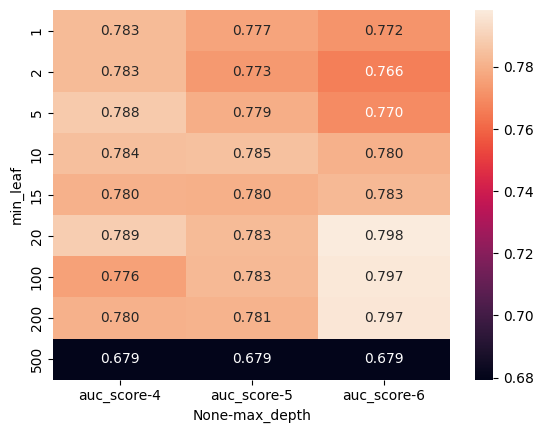

In [37]:
import seaborn as sns
sns.heatmap(df_pivot, annot=True, fmt='.3f')